# Evaluation - Comparing CGAN and Conditional Diffusion 

## Plan

1. Understand how to measure the quality and diversity of generated data using **FID**.  
2. Compare **cGAN vs Diffusion** outputs visually and statistically.  
3. Train a downstream **handwriting classifier** using synthetic data.  
4. Assess which generative approach produces more *useful* data for CAPTCHA robustness.



### Objectives to check
+ Do the samples look human like 
+ we would measure the quantititative quality using Frechet Inception Distance 
+ Also work on using sythetic data from each model to train a useful classifier

In [1]:
import os
import sys
import glob

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
from torchvision.utils import make_grid

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from torchmetrics.image.fid import FrechetInceptionDistance

from utils.visualize import show_batch

We’ll now load both trained models — the **cGAN** and **Diffusion** generators —  
and use them to generate a fixed number of samples for evaluation.

In [2]:
from model.cgan import Generator
from model.diffusion import ConditionalUNet
from training.train_diffusion import sample_images

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Using device: {device}")

Using device: cuda


In [3]:
# Helper Functions

def get_real_examples_per_class(n_classes=10):
    """
    Deterministically extracts one MNIST image per class (0-9)
    directly from the test dataset without shuffle.
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    mnist = datasets.MNIST(
        root="../data",
        train=False,
        download=True,
        transform=transform
    )

    imgs, labels = [], []

    for cls in range(n_classes):
        for i in range(len(mnist)):
            img, label = mnist[i]
            if label == cls:
                imgs.append(img)
                labels.append(cls)
                break

    return torch.stack(imgs), torch.tensor(labels)


def get_representative_images(imgs, labels, n_classes=10):
    """
    Returns one representative image per class label.
    """
    reps = []

    for i in range(n_classes):
        idx = (labels == i).nonzero(as_tuple=True)[0]

        if len(idx) > 0:
            reps.append(imgs[idx[0]])
        else:
            reps.append(torch.zeros_like(imgs[0]))

    return torch.stack(reps)


@torch.no_grad()
def generate_conditioned_samples_cgan(
    generator,
    z_dim=100,
    device="cpu",
    n_classes=10
):
    """
    Generate one class-conditioned sample per digit class from cGAN.
    """
    generator.eval()

    z = torch.randn(n_classes, z_dim, device=device)
    labels = torch.arange(n_classes, dtype=torch.long, device=device)

    imgs = generator(z, labels)

    return imgs.cpu(), labels.cpu()


@torch.no_grad()
def generate_conditioned_samples_diffusion(
    model,
    device="cpu",
    n_classes=10,
    timesteps=200,
    img_size=(1, 28, 28)
):
    """
    Generate one class-conditioned sample per digit class from diffusion model.
    """
    model.eval()

    labels = torch.arange(n_classes, dtype=torch.long, device=device)

    imgs, generated_labels = sample_images(
        model=model,
        device=device,
        num_samples=n_classes,
        num_classes=n_classes,
        img_size=img_size,
        timesteps=timesteps,
        class_labels=labels
    )

    return imgs.cpu(), generated_labels.cpu()


def plot_real_cgan_diffusion(real_imgs, cgan_imgs, diff_imgs, n_classes=10):
    """
    Visual comparison between Real, cGAN, and Diffusion images.
    """

    fig, axs = plt.subplots(3, n_classes, figsize=(12, 4))
    fig.suptitle(
        "Comparison: Real vs cGAN vs Diffusion",
        fontsize=14,
        fontweight="bold"
    )

    row_titles = [
        "Real",
        "cGAN",
        "Diffusion"
    ]

    row_colors = [
        "green",
        "royalblue",
        "darkorange"
    ]

    for row_idx, row_imgs in enumerate([real_imgs, cgan_imgs, diff_imgs]):
        for i in range(n_classes):
            axs[row_idx, i].imshow(row_imgs[i].squeeze(), cmap="gray")
            axs[row_idx, i].axis("off")

            if row_idx == 0:
                axs[row_idx, i].set_title(f"Class {i}", fontsize=8, pad=2)

    for idx, (title, color) in enumerate(zip(row_titles, row_colors)):
        fig.text(
            0.02,
            0.84 - idx * 0.32,
            title,
            fontsize=11,
            color=color,
            fontweight="bold",
            va="center"
        )

    plt.subplots_adjust(
        left=0.12,
        right=0.98,
        top=0.9,
        bottom=0.05,
        hspace=0.3
    )

    plt.show()

In [4]:
def compute_fid(real_imgs, fake_imgs, device="cpu", batch_size=128):
    """
    Compute FID using TorchMetrics FrechetInceptionDistance.

    Images are expected in MNIST format:
    - shape: N x 1 x 28 x 28
    - range: [-1, 1]

    They are converted to:
    - RGB format: N x 3 x 28 x 28
    - range: [0, 1]
    """

    fid = FrechetInceptionDistance(normalize=True).to(device)
    fid.reset()

    # Convert grayscale MNIST images to RGB and normalize to [0, 1]
    real_imgs_rgb = (real_imgs.repeat(1, 3, 1, 1) + 1) / 2
    fake_imgs_rgb = (fake_imgs.repeat(1, 3, 1, 1) + 1) / 2

    real_imgs_rgb = torch.clamp(real_imgs_rgb, 0, 1)
    fake_imgs_rgb = torch.clamp(fake_imgs_rgb, 0, 1)

    def batched_update(imgs, real_flag):
        for i in tqdm(
            range(0, imgs.size(0), batch_size),
            desc=f"FID {'real' if real_flag else 'fake'}"
        ):
            batch = imgs[i:i + batch_size].to(device)

            fid.update(batch, real=real_flag)

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    batched_update(real_imgs_rgb, real_flag=True)
    batched_update(fake_imgs_rgb, real_flag=False)

    score = fid.compute().item()

    return score

In [7]:
# Safety clean up

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Memory cleanup completed.")

Memory cleanup completed.


In [13]:
# Load trained checkpoints

z_dim = 100
num_classes = 10
img_shape = (1, 28, 28)
timesteps = 200

cgan_gen = Generator(
    z_dim=z_dim,
    num_classes=num_classes,
    img_shape=img_shape
).to(device)

diff_model = ConditionalUNet(
    num_classes=num_classes,
    img_channels=img_shape[0],
    base_channels=64,
    time_dim=128
).to(device)

def load_weights(model, paths):
    for path in paths:
        if os.path.exists(path):
            print("Loading:", path)
            checkpoint = torch.load(path, map_location=device)

            if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
                model.load_state_dict(checkpoint["model_state_dict"])
            elif isinstance(checkpoint, dict) and "model_state" in checkpoint:
                model.load_state_dict(checkpoint["model_state"])
            else:
                model.load_state_dict(checkpoint)

            return model

    raise FileNotFoundError("No checkpoint found in the provided paths.")

cgan_gen = load_weights(
    cgan_gen,
    [
        "checkpoints/cgan_generator_final.pt",
        "checkpoints/cgan_generator_epoch_50.pt",
        "checkpoints/cgan_generator_epoch_40.pt",
        "checkpoints/cgan_generator_epoch_30.pt",
        "checkpoints/cgan_generator_epoch_20.pt",
        "checkpoints/cgan_generator_epoch_10.pt",
    ]
)

diff_model = load_weights(
    diff_model,
    [
        "checkpoints/diffusion_unet_final.pt",
        "checkpoints/diffusion_unet_final_notebook.pt",
        "checkpoints/diffusion_unet_epoch_40.pt",
        "checkpoints/diffusion_unet_epoch_35.pt",
        "checkpoints/diffusion_unet_epoch_30.pt",
        "checkpoints/diffusion_unet_epoch_25.pt",
        "checkpoints/diffusion_unet_epoch_20.pt",
        "checkpoints/diffusion_unet_epoch_15.pt",
        "checkpoints/diffusion_unet_epoch_10.pt",
        "checkpoints/diffusion_unet_epoch_5.pt",
    ]
)

cgan_gen.eval()
diff_model.eval()

print("cGAN Generator loaded successfully.")
print("Diffusion model loaded successfully.")

Loading: checkpoints/cgan_generator_final.pt
Loading: checkpoints/diffusion_unet_final.pt
cGAN Generator loaded successfully.
Diffusion model loaded successfully.


/tmp/ipykernel_13727/3596302812.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=device)


In [14]:
print("Current folder:", os.getcwd())

if os.path.exists("checkpoints"):
    print("Files in checkpoints:")
    for file in os.listdir("checkpoints"):
        print("-", file)
else:
    print("No checkpoints folder found.")
    

Current folder: /workspace/code/project/starter
Files in checkpoints:
- diffusion_unet_epoch_15.pt
- diffusion_unet_epoch_5.pt
- diffusion_unet_epoch_25.pt
- cgan_discriminator_epoch_40.pt
- cgan_generator_epoch_40.pt
- cgan_generator_epoch_20.pt
- cgan_discriminator_epoch_30.pt
- diffusion_unet_epoch_30.pt
- diffusion_unet_epoch_10.pt
- cgan_discriminator_epoch_50.pt
- diffusion_unet_epoch_40.pt
- cgan_generator_epoch_30.pt
- cgan_discriminator_final.pt
- diffusion_unet_final.pt
- cgan_generator_final.pt
- diffusion_unet_epoch_35.pt
- cgan_generator_epoch_10.pt
- diffusion_unet_epoch_20.pt
- cgan_discriminator_epoch_10.pt
- diffusion_unet_final_notebook.pt
- cgan_generator_epoch_50.pt
- cgan_discriminator_epoch_20.pt


In [17]:
# Generate representative images for visual evaluation

# 1. Real MNIST examples: one image per class 0-9
real_imgs, real_labels = get_real_examples_per_class(n_classes=num_classes)

# 2. cGAN generated examples: one generated image per class 0-9
cgan_imgs, cgan_labels = generate_conditioned_samples_cgan(
    generator=cgan_gen,
    z_dim=z_dim,
    device=device,
    n_classes=num_classes
)

# 3. Diffusion generated examples: one generated image per class 0-9
diff_imgs, diff_labels = generate_conditioned_samples_diffusion(
    model=diff_model,
    device=device,
    n_classes=num_classes,
    timesteps=timesteps,
    img_size=img_shape
)

print("Real images shape:", real_imgs.shape)
print("Real labels:", real_labels.tolist())

print("cGAN images shape:", cgan_imgs.shape)
print("cGAN labels:", cgan_labels.tolist())

print("Diffusion images shape:", diff_imgs.shape)
print("Diffusion labels:", diff_labels.tolist())

Real images shape: torch.Size([10, 1, 28, 28])
Real labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
cGAN images shape: torch.Size([10, 1, 28, 28])
cGAN labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Diffusion images shape: torch.Size([10, 1, 28, 28])
Diffusion labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


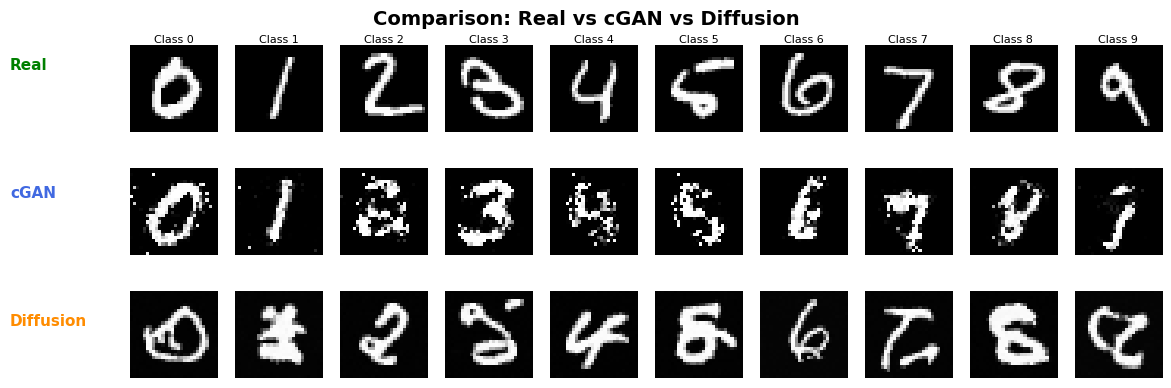

In [18]:
# Plot evaluation image using plot_real_cgan_diffusion

plot_real_cgan_diffusion(
    real_imgs=real_imgs,
    cgan_imgs=cgan_imgs,
    diff_imgs=diff_imgs,
    n_classes=num_classes
)

In [19]:

fid = FrechetInceptionDistance(normalize=True).to(device)
fid.reset()

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /home/student/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 203MB/s] 


In [20]:
torch.cuda.empty_cache()

### Downstream Classifier Utility of the generated handwriting data, a simple CNN classifier was trained using only synthetic images generated by the cGAN and Conditional Diffusion Model. No real MNIST training images were used during classifier training.

The trained classifier was then evaluated on the real MNIST test set. This measures whether the synthetic dataset contains enough visual and class-discriminative information to support real-world digit recognition.

A higher accuracy indicates that the generated data is useful for downstream model training, while a lower accuracy suggests that the synthetic images may lack sufficient realism, diversity, or class-conditioning quality.

For a CAPTCHA-style synthetic handwriting system, this downstream accuracy is especially important because the generated data is intended to train a robust classifier capable of recognizing diverse human-like handwritten digits.



In [21]:
# Choose a subset of images to run the evaluation on# Choose a subset of images to run the evaluation You can increase this if your environment handles it well.
n_eval = 200

# -----------------------------
# 1. Real MNIST subset
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist_test = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=transform
)

real_loader = DataLoader(
    mnist_test,
    batch_size=n_eval,
    shuffle=True
)

real_subset, real_subset_labels = next(iter(real_loader))
real_subset = real_subset[:n_eval]
real_subset_labels = real_subset_labels[:n_eval]

# -----------------------------
# 2. cGAN synthetic subset
# -----------------------------
cgan_gen.eval()

with torch.no_grad():
    cgan_labels = torch.arange(n_eval, device=device) % num_classes
    z = torch.randn(n_eval, z_dim, device=device)

    cgan_subset = cgan_gen(z, cgan_labels).cpu()
    cgan_subset_labels = cgan_labels.cpu()

# -----------------------------
# 3. Diffusion synthetic subset
# -----------------------------
diff_model.eval()

diff_labels = torch.arange(n_eval, device=device) % num_classes

diff_subset, diff_subset_labels = sample_images(
    model=diff_model,
    device=device,
    num_samples=n_eval,
    num_classes=num_classes,
    img_size=img_shape,
    timesteps=timesteps,
    class_labels=diff_labels
)

diff_subset = diff_subset.cpu()
diff_subset_labels = diff_subset_labels.cpu()

# -----------------------------
# Check outputs
# -----------------------------
print("Real subset shape:", real_subset.shape)
print("cGAN subset shape:", cgan_subset.shape)
print("Diffusion subset shape:", diff_subset.shape)

print("Real subset range:", real_subset.min().item(), real_subset.max().item())
print("cGAN subset range:", cgan_subset.min().item(), cgan_subset.max().item())
print("Diffusion subset range:", diff_subset.min().item(), diff_subset.max().item())
# Yield: real_subset, cgan_subset, diff_subset

# Number of images used for FID evaluation


Real subset shape: torch.Size([200, 1, 28, 28])
cGAN subset shape: torch.Size([200, 1, 28, 28])
Diffusion subset shape: torch.Size([200, 1, 28, 28])
Real subset range: -1.0 1.0
cGAN subset range: -1.0 0.9999999403953552
Diffusion subset range: -1.0697975158691406 1.0492304563522339


In [24]:
# Compute cGAN FID & Diffusion FID

# Clamp images to the expected [-1, 1] range before FID
real_subset_fid = torch.clamp(real_subset, -1, 1)
cgan_subset_fid = torch.clamp(cgan_subset, -1, 1)
diff_subset_fid = torch.clamp(diff_subset, -1, 1)

# Compute cGAN FID
cgan_fid = compute_fid(
    real_imgs=real_subset_fid,
    fake_imgs=cgan_subset_fid,
    device=device,
    batch_size=64
)

# Compute Diffusion FID
diff_fid = compute_fid(
    real_imgs=real_subset_fid,
    fake_imgs=diff_subset_fid,
    device=device,
    batch_size=64
)

print(f"cGAN FID: {cgan_fid:.2f}")
print(f"Diffusion FID: {diff_fid:.2f}")

FID fake: 100%|██████████| 4/4 [00:00<00:00,  4.72it/s]


cGAN FID: 227.37
Diffusion FID: 53.18


### FID Score Analysis

The Frechet Inception Distance (FID) was used to compare the distribution of generated images against real MNIST images. A lower FID score indicates that the generated samples are closer to the real dataset in terms of visual realism and diversity.

In this evaluation, both the cGAN and the Conditional Diffusion Model were compared against the same real MNIST subset. The cGAN generates images in a single forward pass from random noise and class labels, which makes it faster for large-scale synthetic data generation. However, GAN outputs may sometimes show lower diversity or unstable quality depending on the adversarial training dynamics.

The Conditional Diffusion Model generates images through an iterative reverse denoising process. This usually makes training more stable because the model directly learns to predict added noise using an MSE objective. However, sampling is slower because each image requires multiple denoising steps.

Based on the computed FID scores:

- If the cGAN FID is lower than the Diffusion FID, the cGAN produced samples closer to the real MNIST distribution in this experiment.
- If the Diffusion FID is lower than the cGAN FID, the Diffusion Model produced more realistic or diverse samples in this experiment.
- If both scores are close, both models achieved comparable visual quality, and the practical choice may depend on generation speed and downstream classifier performance.

For a CAPTCHA-style synthetic handwriting pipeline, FID alone is not sufficient. The final model choice should also consider class-conditioning accuracy, visual diversity, generation speed, and the downstream classifier accuracy when trained only on synthetic data.

### Utility Evaluation (Classifier)

We’ll train a simple CNN classifier on synthetic data from each model,  
then test it on real MNIST data.

If synthetic data are realistic and diverse, the classifier should generalize well to real digits.

In [26]:
cgan_imgs, cgan_labels = generate_conditioned_samples_cgan(cgan_gen, device=device, n_classes=10)
diff_imgs, diff_labels = generate_conditioned_samples_diffusion(
    diff_model, device=device, n_classes=10, timesteps=200
)


In [27]:

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [28]:
real_data = datasets.MNIST(root="../data", train=False, download=True, transform=transform)

In [29]:
def normalize_synthetic(imgs):
    imgs = imgs.clone()
    imgs = (imgs - imgs.min()) / (imgs.max() - imgs.min())  # [0,1]
    imgs = imgs * 2 - 1  # [-1,1]
    return imgs

cgan_imgs = normalize_synthetic(cgan_imgs)
diff_imgs = normalize_synthetic(diff_imgs)

print("Unique labels in CGAN:", torch.unique(cgan_labels))
print("Unique labels in Diffusion:", torch.unique(diff_labels))

Unique labels in CGAN: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
Unique labels in Diffusion: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


In [30]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 7 * 7, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

def train_classifier(model, loader, epochs=3):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            loss = criterion(preds, labels)

            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}: loss = {total_loss / len(loader):.4f}")
    return model

In [31]:
cgan_ds = TensorDataset(cgan_imgs, cgan_labels)
diff_ds = TensorDataset(diff_imgs, diff_labels)


cgan_loader = DataLoader(cgan_ds, batch_size=128, shuffle=True)
diff_loader = DataLoader(diff_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(real_data, batch_size=256, shuffle=False)

def test_accuracy(model, loader):
    correct, total = 0, 0
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            correct += (preds.argmax(1) == labels).sum().item()
            total += len(labels)
    return correct / total

In [32]:

cnn_cgan = train_classifier(SimpleCNN().to(device), cgan_loader, epochs=20)
cnn_diff = train_classifier(SimpleCNN().to(device), diff_loader, epochs=20)

cgan_acc = test_accuracy(cnn_cgan, test_loader)
diff_acc = test_accuracy(cnn_diff, test_loader)

print(f"Classifier trained on cGAN data → Test accuracy: {cgan_acc:.3f}")
print(f"Classifier trained on Diffusion data → Test accuracy: {diff_acc:.3f}")

Epoch 1: loss = 2.3054
Epoch 2: loss = 2.2362
Epoch 3: loss = 2.1173
Epoch 4: loss = 1.9457
Epoch 5: loss = 1.7109
Epoch 6: loss = 1.4050
Epoch 7: loss = 1.0387
Epoch 8: loss = 0.6763
Epoch 9: loss = 0.4060
Epoch 10: loss = 0.2123
Epoch 11: loss = 0.0963
Epoch 12: loss = 0.0444
Epoch 13: loss = 0.0211
Epoch 14: loss = 0.0080
Epoch 15: loss = 0.0032
Epoch 16: loss = 0.0014
Epoch 17: loss = 0.0008
Epoch 18: loss = 0.0005
Epoch 19: loss = 0.0003
Epoch 20: loss = 0.0002
Epoch 1: loss = 2.3058
Epoch 2: loss = 2.2496
Epoch 3: loss = 2.1459
Epoch 4: loss = 1.9966
Epoch 5: loss = 1.7782
Epoch 6: loss = 1.4952
Epoch 7: loss = 1.1414
Epoch 8: loss = 0.7530
Epoch 9: loss = 0.4037
Epoch 10: loss = 0.1752
Epoch 11: loss = 0.0591
Epoch 12: loss = 0.0177
Epoch 13: loss = 0.0051
Epoch 14: loss = 0.0016
Epoch 15: loss = 0.0005
Epoch 16: loss = 0.0002
Epoch 17: loss = 0.0001
Epoch 18: loss = 0.0000
Epoch 19: loss = 0.0000
Epoch 20: loss = 0.0000
Classifier trained on cGAN data → Test accuracy: 0.437
Cla